"Global Temperature Time Series" dataset, which contains monthly temperature anomalies from 1880 to present day.

Task: Global Temperature Forecasting
To analyze the global temperature time series and build forecasting models to predict future temperature trends. 

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.utils.plotting import plot_series

# Load the dataset (NASA GISTEMP Global Temperature Anomaly)
url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

In [3]:
# Data preparation
def prepare_nasa_data(url):
    # Read the data, skipping the header explanation
    df = pd.read_csv(url, skiprows=1)

    # Remove the unnecessary columns
    df = df.iloc[:, :13]

    # Rename columns
    df.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Convert from wide to long format
    df_long = df.melt(id_vars=['Year'],
                       var_name='Month',
                       value_name='Temperature_Anomaly')

    # Filter out missing or invalid data
    df_long = df_long[df_long['Temperature_Anomaly'] != '***']
    df_long['Temperature_Anomaly'] = df_long['Temperature_Anomaly'].astype(float)

    # Create a proper date index
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['Month'], format='%Y-%b')

    # Sort by date
    df_long = df_long.sort_values('Date')

    # Create a time series
    ts_data = df_long.set_index('Date')['Temperature_Anomaly']

    return ts_data

# Prepare the time series data
ts_data = prepare_nasa_data(url)

# Now you have a time series object 'ts_data' to work with
print(f"Time series data from {ts_data.index.min()} to {ts_data.index.max()}")
print(f"Total number of observations: {len(ts_data)}")

Time series data from 1880-01-01 00:00:00 to 2026-02-01 00:00:00
Total number of observations: 1754


In [83]:
ts_data

Date
1880-01-01   -0.19
1880-02-01   -0.25
1880-03-01   -0.09
1880-04-01   -0.16
1880-05-01   -0.10
              ... 
2025-10-01    1.19
2025-11-01    1.21
2025-12-01    1.07
2026-01-01    1.08
2026-02-01    1.24
Name: Temperature_Anomaly, Length: 1754, dtype: float64

### Plots

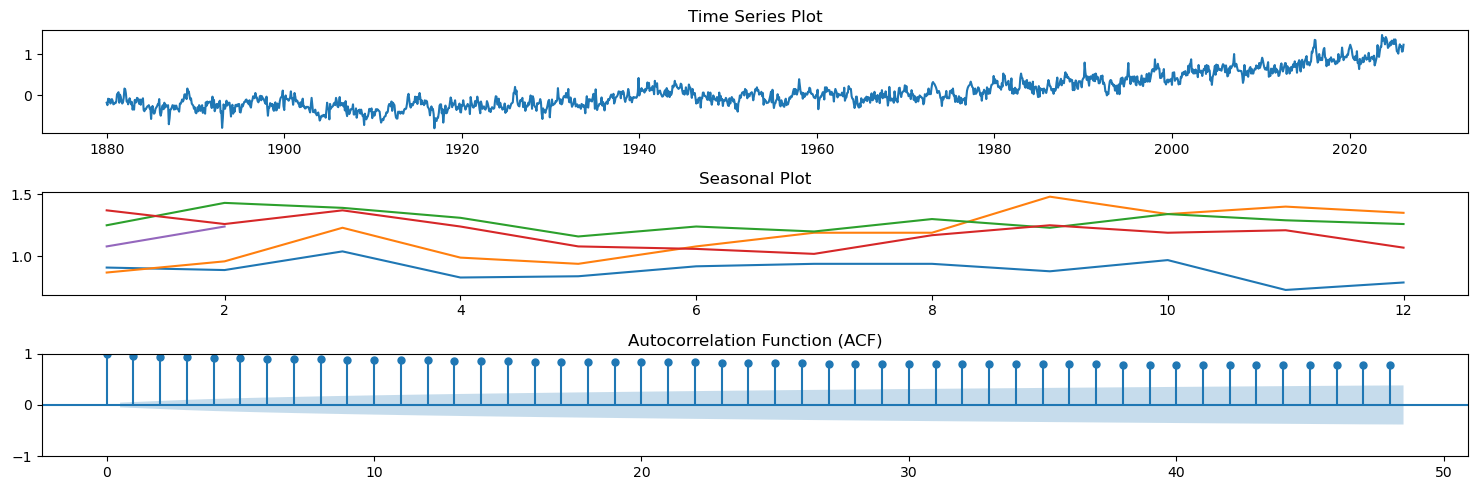

In [62]:
# Plots - time series, seasonal, ACF
fig, axes = plt.subplots(3, 1, figsize=(15, 5))

axes[0].plot(ts_data.index, ts_data.values)
axes[0].set_title('Time Series Plot')

selected_year_data = ts_data.loc[ts_data.index.year >= 2022]
years = selected_year_data.index.year.unique()
for year in years:
    axes[1].plot(ts_data[ts_data.index.year == year].index.month, ts_data[ts_data.index.year == year], label=year)
axes[1].set_title('Seasonal Plot')

plot_acf(ts_data, lags=48, ax=axes[2])
axes[2].set_title('Autocorrelation Function (ACF)')

plt.tight_layout()
plt.show()

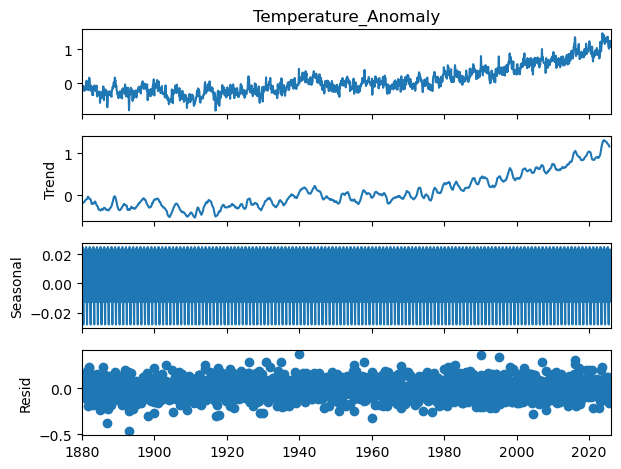

ValueError: Multiplicative seasonality is not appropriate for zero and negative values

In [74]:
# Perform additive decomposition
decomposition = seasonal_decompose(ts_data, model='additive')
# Plot the decomposed components
fig = decomposition.plot()
plt.show()

# Perform multiplicative decomposition --> error: not appropriate
decomposition = seasonal_decompose(ts_data, model='multiplicative')

# Plot the decomposed components
fig = decomposition.plot()
plt.show()

### Temporal data split 

In [151]:
# Split data into training and testing sets with the last 36 months as test data
ts_train, ts_test = temporal_train_test_split(ts_data, test_size=36)

print(ts_train.shape, ts_train.index.min(), ts_train.index.max())
print(ts_test.shape, ts_test.index.min(), ts_test.index.max())

(1718,) 1880-01-01 00:00:00 2023-02-01 00:00:00
(36,) 2023-03-01 00:00:00 2026-02-01 00:00:00


### Models, predict, evaluate

In [152]:
# .predict(fh=fh) throws error "invalid frequency"
# therefore, convert DatetimeIndex to PeriodIndex before fitting
ts_test.index = pd.PeriodIndex(ts_test.index, freq='M') # or 'D', 'Q', 'Y', 'H'
ts_train.index = pd.PeriodIndex(ts_train.index, freq='M') # or 'D', 'Q', 'Y', 'H'

In [153]:
# AutoARIMA model (runtime ~4)
auto_arima_model = AutoARIMA(sp=12, suppress_warnings=True, stepwise=True)
auto_arima_model.fit(ts_train)
auto_arima_model.get_fitted_params()

{'ar.L1': 0.8490457640311583,
 'ma.L1': -1.3465081476578304,
 'ma.L2': 0.36209409018174926,
 'ar.S.L12': 0.05767460170655206,
 'ar.S.L24': 0.1162619132109356,
 'sigma2': 0.011393728124918338,
 'order': (1, 1, 2),
 'seasonal_order': (2, 0, 0, 12),
 'aic': -2797.018168299689,
 'aicc': -2796.9690454926713,
 'bic': -2764.328165134304,
 'hqic': -2784.9222839251233}

In [154]:
# AutoETS model (runtime ~2s)
auto_ets_model = AutoETS(auto=True, sp=12, n_jobs=-1)
auto_ets_model.fit(ts_train)
auto_ets_model.get_fitted_params()

/home/jasmine/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/adapters/_statsmodels.py:54: UserWarning: Warning: time series is not strictly positive, multiplicative components are omitted
  self._fit_forecaster(y, X)


{'aic': -2705.921433037195,
 'aicc': -2705.907430703473,
 'bic': -2689.5746847295627,
 'hqic': -2699.8730218439023}

In [155]:
# Define the forecasting horizon --> list 1 to 36
fh = np.arange(1, len(ts_test) + 1)

# Forecast the next 36 months
y_pred_autoarima = auto_arima_model.predict(fh=fh)
y_pred_autoets = auto_ets_model.predict(fh=fh)

# Evaluate sMAPE for each model --> similar results
print("sMAPE AutoARIMA:", mean_absolute_percentage_error(ts_test, y_pred_autoarima, symmetric=True))
print("sMAPE AutoETS:", mean_absolute_percentage_error(ts_test, y_pred_autoets, symmetric=True))

sMAPE AutoARIMA: 0.2991140944868771
sMAPE AutoETS: 0.301808211829312


/home/jasmine/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jasmine/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jasmine/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jasmine/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Temperature_Anomaly'>)

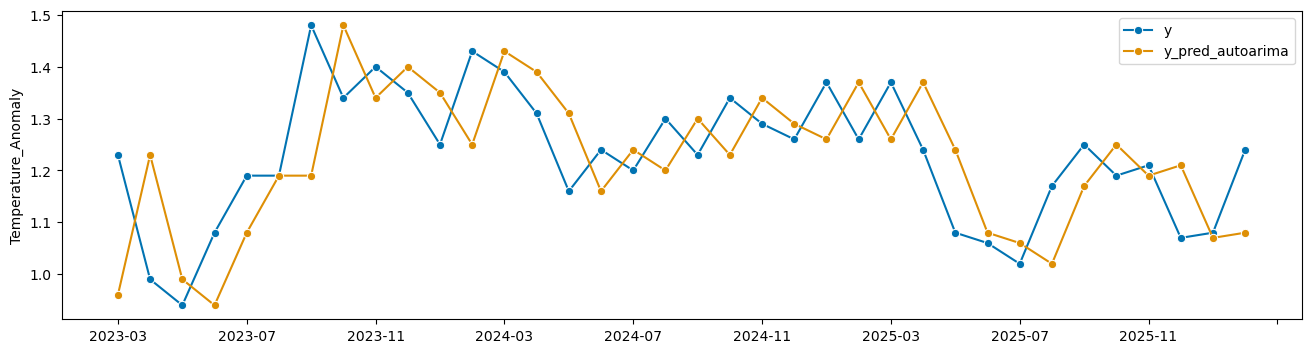

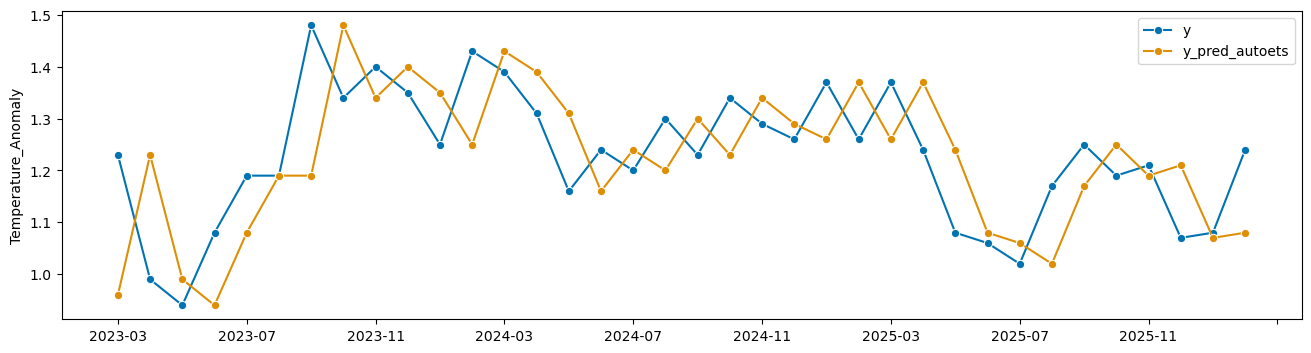

In [164]:
# visualize forecast with the best performing model
history = ts_train.copy()
pred_vals = []

for stamp in ts_test.index:
    pred_vals.append(history.iloc[-1])          # forecast using current history
    history.loc[stamp] = ts_test.loc[stamp]      # once actual arrives, add it

y_pred_autoarima = pd.Series(pred_vals, index=ts_test.index)
y_pred_autoets = pd.Series(pred_vals, index=ts_test.index)

plot_series(ts_test, y_pred_autoarima, labels=["y", "y_pred_autoarima"])
plot_series(ts_test, y_pred_autoets, labels=["y", "y_pred_autoets"])

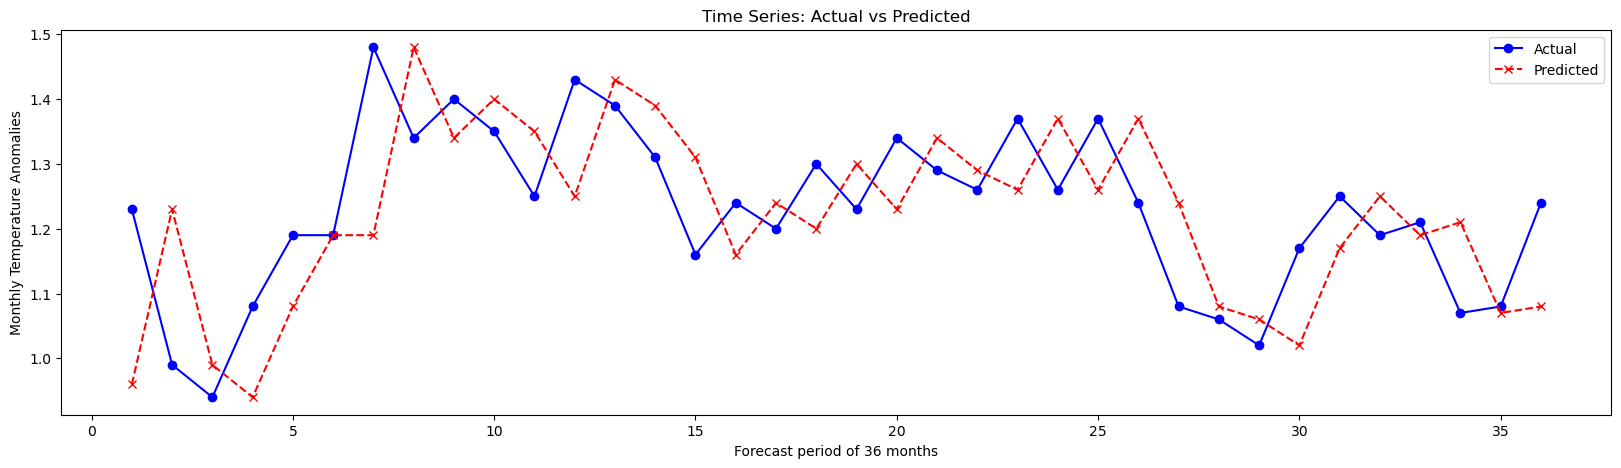

In [169]:
# Alternative plotting
plt.figure(figsize=(20, 5))
plt.plot(fh, ts_test, label='Actual', color='blue', marker='o')  # Plot actual test data
plt.plot(fh, y_pred_autoets, label='Predicted', color='red', linestyle='--', marker='x') # Plot predicted data
plt.title('Time Series: Actual vs Predicted')
plt.xlabel('Forecast period of 36 months')
plt.ylabel('Monthly Temperature Anomalies')
plt.legend()  # to display label in .plot

### Given solution 
(but with errors, not fully executable)

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error, mean_absolute_error
from sktime.utils.plotting import plot_series

# Load the dataset (NASA GISTEMP Global Temperature Anomaly)
url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

# Data preparation
def prepare_nasa_data(url):
    # Read the data, skipping the header explanation
    df = pd.read_csv(url, skiprows=1)

    # Remove the unnecessary columns
    df = df.iloc[:, :13]

    # Rename columns
    df.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Convert from wide to long format
    df_long = df.melt(id_vars=['Year'],
                       var_name='Month',
                       value_name='Temperature_Anomaly')

    # Filter out missing or invalid data
    df_long = df_long[df_long['Temperature_Anomaly'] != '***']
    df_long['Temperature_Anomaly'] = df_long['Temperature_Anomaly'].astype(float)

    # Create a proper date index
    df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['Month'], format='%Y-%b')

    # Sort by date
    df_long = df_long.sort_values('Date')

    # Create a time series
    ts_data = df_long.set_index('Date')['Temperature_Anomaly']

    return ts_data

# Prepare the time series data
ts_data = prepare_nasa_data(url)

# Now you have a time series object 'ts_data' to work with
print(f"Time series data from {ts_data.index.min()} to {ts_data.index.max()}")
print(f"Total number of observations: {len(ts_data)}")

# Data Exploration
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values)
plt.title('Global Temperature Anomalies (1880-Present)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Check for seasonality using a seasonal plot
plt.figure(figsize=(14, 6))
year_data = ts_data['2010':'2020']
year_data.groupby(year_data.index.month).mean().plot(kind='bar')
plt.title('Average Monthly Temperature Anomaly (2010-2020)')
plt.xlabel('Month')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Autocorrelation Function (ACF)
plt.figure(figsize=(14, 6))
plot_acf(ts_data, lags=48)
plt.title('Autocorrelation Function (ACF)')
plt.tight_layout()
plt.show()

# Time Series Decomposition
# Additive decomposition
decomposition_add = seasonal_decompose(ts_data, model='additive', period=12)

plt.figure(figsize=(14, 12))
plt.subplot(411)
plt.plot(ts_data, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition_add.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition_add.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition_add.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Multiplicative decomposition
decomposition_mult = seasonal_decompose(ts_data, model='multiplicative', period=12)

plt.figure(figsize=(14, 12))
plt.subplot(411)
plt.plot(ts_data, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition_mult.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition_mult.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition_mult.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Observations from decomposition:
# We can see a clear upward trend in the temperature anomalies over time
# There is a consistent seasonal pattern within each year
# The additive model appears to fit better as there's no obvious change
# in the amplitude of seasonal variations over time

# Split the data into training and testing sets
train, test = temporal_train_test_split(ts_data, test_size=36)
print(f"Training data: {len(train)} observations from {train.index.min()} to {train.index.max()}")
print(f"Testing data: {len(test)} observations from {test.index.min()} to {test.index.max()}")

# Visualize the split
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Training Data')
plt.plot(test.index, test.values, label='Testing Data')
plt.title('Train-Test Split of Global Temperature Anomalies')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Forecast horizon
fh = np.arange(1, len(test) + 1)

# Model 1: Naive Forecasting (last value)
naive_forecaster = NaiveForecaster(strategy="last")
naive_forecaster.fit(train)
y_pred_naive = naive_forecaster.predict(fh)

# Model 2: Seasonal Naive Forecasting
seasonal_naive_forecaster = NaiveForecaster(strategy="seasonal_last", sp=12)
seasonal_naive_forecaster.fit(train)
y_pred_seasonal_naive = seasonal_naive_forecaster.predict(fh)

# Model 3: AutoARIMA
arima_forecaster = AutoARIMA(sp=12, suppress_warnings=True)
arima_forecaster.fit(train)
y_pred_arima = arima_forecaster.predict(fh)
print(f"Best ARIMA model: {arima_forecaster.get_fitted_params()}")

# Model 4: ETS
ets_forecaster = AutoETS(auto=True, sp=12, n_jobs=-1)
ets_forecaster.fit(train)
y_pred_ets = ets_forecaster.predict(fh)
print(f"Best ETS model: {ets_forecaster.get_fitted_params()}")

# Visualize forecasts
plt.figure(figsize=(14, 6))
plot_series(train, test, y_pred_naive, y_pred_seasonal_naive, y_pred_arima, y_pred_ets,
            labels=['Training', 'Testing', 'Naive', 'Seasonal Naive', 'ARIMA', 'ETS'])
plt.title('Global Temperature Forecasts')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare model performance using appropriate metrics
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    # Calculate RMSE manually
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    return {'Model': model_name, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse}

# Evaluation
results = []
results.append(evaluate_forecast(test, y_pred_naive, 'Naive'))
results.append(evaluate_forecast(test, y_pred_seasonal_naive, 'Seasonal Naive'))
results.append(evaluate_forecast(test, y_pred_arima, 'ARIMA'))
results.append(evaluate_forecast(test, y_pred_ets, 'ETS'))

# Convert to DataFrame for better display
results_df = pd.DataFrame(results)
print("Performance Metrics:")
print(results_df)

# Find the best model based on MAE
best_model_idx = results_df['MAE'].argmin()
best_model_name = results_df.iloc[best_model_idx]['Model']
print(f"The best performing model is {best_model_name} with MAE of {results_df.iloc[best_model_idx]['MAE']:.4f}")

# Generate future forecasts with the best model
# For this example, let's use the ARIMA model to forecast 24 months into the future
full_data = ts_data
future_fh = np.arange(1, 25)  # 24 months ahead

# Re-fit the best model on the full data
if best_model_name == 'ARIMA':
    best_forecaster = arima_forecaster
elif best_model_name == 'ETS':
    best_forecaster = ets_forecaster
elif best_model_name == 'Seasonal Naive':
    best_forecaster = seasonal_naive_forecaster
else:
    best_forecaster = naive_forecaster

best_forecaster.fit(full_data)
future_forecast = best_forecaster.predict(future_fh)

# Visualize the future forecast
plt.figure(figsize=(14, 6))
plt.plot(full_data.index[-60:], full_data.values[-60:], label='Historical Data')
plt.plot(future_forecast.index, future_forecast.values, color='red', label='Forecast')
plt.title(f'Future Forecast using {best_model_name} Model')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Forecast values for the next 24 months:")
print(future_forecast)

# Interpretation of results
print("\nInterpretation of Results:")
print("1. The global temperature anomaly data shows a clear upward trend over the time period.")
print("2. There is a seasonal pattern in the data with higher temperatures typically in certain months.")
print(f"3. The {best_model_name} model performed best, likely due to its ability to capture both trend and seasonality.")
print("4. The forecasts suggest a continuing increase in global temperature anomalies.")
print("5. These findings align with climate change research showing global warming trends.")